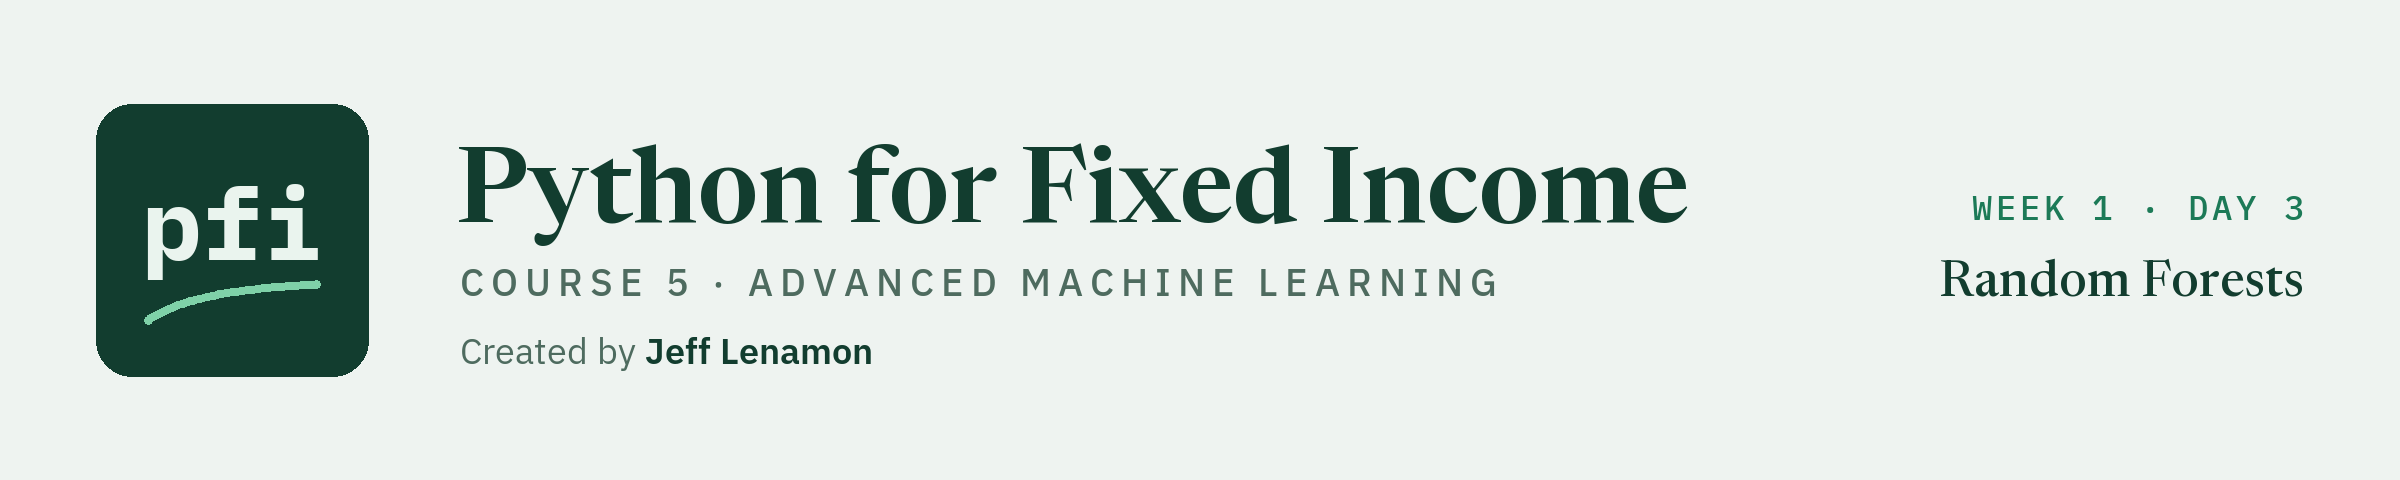

# Random Forests

Week 1, Day 3. Averaging trees removes only the part of their noise they do not share. Today: how much an ensemble's trees agree, the random forest's random columns at every split, and what matters more on the card file, the number of trees or the size of their leaves.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week1/day3/03_random_forests.ipynb)

Day 2 averaged 100 full trees fitted on bootstrap samples and ranked the validation accounts far better than any one tree. It also showed what bagging cannot change: every one of those trees asks about `PAY_0` first. Trees grown from the same columns on similar rows tend to make the same choices, and an average of trees that agree removes less noise than an average of trees that do not. A **random forest** makes the trees differ on purpose: at every split, each tree may only choose among a few columns drawn at random. Today measures how much that changes the trees, and how much it changes the model.

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` holds 30,000 credit card accounts with payment records from April to September 2005 and an outcome for the following month. The accounts are in Taiwan in 2005, and consumer credit there differs from US credit. Nothing here describes any other market.
* **People's attributes are never features.** `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` are not used by any model in this course, and no output is grouped by them. Every model today uses the other 19 columns.
* **Course 4's split, rebuilt.** 18,000 training rows fit and choose, 6,000 validation rows report, and Course 4's 6,000 test rows stay closed, by day 1's test-row rule.
* **A model's output is described, never acted on.** A forest's output is the model probability of default in this file, or a flag at a threshold; a forest fitted with class weights gives the model's score. No output of either kind is a credit decision for any person.

Today you will:

1. Measure how much the trees of day 2's bagged model agree, with a new function, `tree_correlation`.
2. See what `max_features="sqrt"` does to the questions the trees ask first.
3. Fit a random forest beside the bagged model and compare their agreement and their ranking.
4. Vary leaf size and tree count, and see which one matters on this file.
5. Show that a forest with `max_features=None` is bagging.
6. Fit a forest with class weights and say what its output is.
7. Choose a leaf size by five folds of the training rows.
8. Fit one forest of extremely randomized trees.

Q. Set up today's work folder: the thread settings, the seed, the card file, and the modules as day 2 left them.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_03_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_03_6eve2eqj, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc']


* The modules are day 2's: `mlkit.py` from Course 4, unchanged, and `ensemblekit.py` with `course4_card_rows`, `bootstrap_positions`, `out_of_bag`, `bagged_proba`, and `oob_auc`, with their 11 tests. Today adds one function.

## 3.1 Trees That Agree Do Not Average Away Much

Take B numbers that each vary by the same amount (variance sigma squared) and move together with correlation rho between any two. Their average has variance

rho x sigma^2 + (1 - rho) x sigma^2 / B.

More numbers shrink the second term towards zero; nothing shrinks the first. If the trees of an ensemble agree perfectly (rho = 1), averaging them removes nothing; if they share nothing (rho = 0), a large enough average removes all of their noise. So the question for an ensemble is how much its trees agree, and today's function measures it on the validation accounts.

Q. Add `tree_correlation` to `ensemblekit.py`. Read the docstring first.

In [6]:
%%writefile -a ensemblekit.py


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())

Appending to ensemblekit.py


* Each tree scores the validation rows, which gives one column of outputs per tree. `np.corrcoef` correlates every pair of columns; the function averages the pairs above the diagonal, so each pair counts once and no tree is compared with itself.
* A bagged model may give each tree its own order of columns (`estimators_features_`), so the function scores each tree on its own columns, as `bagged_proba` did on day 2. A forest has no such list, and every tree gets all the columns.

Q. Add its three tests: a hand case, a forest against bagging, and a refusal.

In [7]:
%%writefile -a test_ensemblekit.py


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)

Appending to test_ensemblekit.py


* The hand test needs no fitting: two stand-in trees whose outputs differ by a constant must have correlation exactly 1. The second test fits a 10-tree bagged model and a 10-tree forest on 3,000 training rows and checks the forest's trees agree less on the validation rows. The third checks that one tree is refused, since one tree has no pair.

Q. Reload the module and run the tests.

In [8]:
# the file changed, so reload before using the new function
importlib.reload(ensemblekit)
print(f"tree_correlation in ensemblekit: {hasattr(ensemblekit, 'tree_correlation')}")

tree_correlation in ensemblekit: True


In [9]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..............                                                           [100%]
14 passed in 33.53s



* `14 passed`: day 2's 11 and today's 3.

Q. Load Course 4's rows and refit day 2's bagged model: 100 full trees on bootstrap samples.

In [10]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

# Course 4's split, rebuilt: training and validation rows only, with the 19 model columns
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"

# day 2's model: 100 full trees, each on its own bootstrap sample of the training rows
bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=100, random_state=SEED, n_jobs=1)
bagging.fit(X_train, y_train)
proba_bag = bagging.predict_proba(X_valid)[:, 1]
print(f"bagging, 100 full trees: validation ROC AUC {roc_auc_score(y_valid, proba_bag):.4f}, "
      f"average precision {average_precision_score(y_valid, proba_bag):.4f}")

bagging, 100 full trees: validation ROC AUC 0.7602, average precision 0.5105


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows and scored on Course 4's 6,000 validation rows; Course 4's 6,000 test rows are never scored in this course.

* 0.7602, day 2's bagged model refitted with the same seed. Its output is the model probability of default in this file: the average of 100 trees' outputs.

Q. How much do its 100 trees agree, and what does each tree ask first?

In [11]:
# each tree's output on the validation rows, on its own columns: one row per tree
values = X_valid.to_numpy(dtype=float)
bag_outputs = np.array([tree.predict_proba(values[:, columns])[:, 1]
                        for tree, columns in zip(bagging.estimators_, bagging.estimators_features_)])

# the column each tree asks about first (a tree's columns are in its own order, so map them back)
bag_first = pd.Series([X_train.columns[columns[tree.tree_.feature[0]]]
                       for tree, columns in zip(bagging.estimators_, bagging.estimators_features_)])

print(f"tree correlation, bagging: {ensemblekit.tree_correlation(bagging, X_valid):.4f}")
print(f"correlation of trees 1 and 2 alone: {np.corrcoef(bag_outputs[0], bag_outputs[1])[0, 1]:.4f}")
print(f"first question about: {bag_first.value_counts().to_dict()}")

tree correlation, bagging: 0.2581
correlation of trees 1 and 2 alone: 0.2564
first question about: {'PAY_0': 100}


* The 100 trees' outputs have an average pairwise correlation of 0.2581 on the validation accounts (trees 1 and 2 alone: 0.2564). That is low: full trees give mostly 0 or 1, and two of them disagree on many accounts, which is why averaging them helped so much on day 2.
* And yet all 100 trees ask about `PAY_0` first. Bootstrap samples differ in which rows they repeat, not in which column is strongest, so every tree starts from the same question. The random forest attacks that directly.

## 3.2 A Random Subset of Columns at Every Split

A random forest is bagging with one change. At every split of every tree, the tree draws a few columns at random and may only choose its question among them. The number drawn is `max_features`. For a classifier the default is `"sqrt"`: the square root of the number of columns, rounded down. With 19 columns that is 4.

A column the tree cannot see at a split cannot be chosen there, so a tree whose draw at the root misses `PAY_0` must start with another question.

Q. Fit a random forest of 300 full trees, and check how many columns each split tried.

In [12]:
from math import comb

from sklearn.ensemble import RandomForestClassifier

# 300 full trees on bootstrap samples; each split chooses among sqrt(19), rounded down, columns drawn at random
forest = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=1)
forest.fit(X_train, y_train)

# the forest stores the setting; each fitted tree stores the number it used
n_columns = X_train.shape[1]
print(f"max_features setting: {forest.max_features!r}; columns tried at each split: {forest.estimators_[0].max_features_} of {n_columns}")
# the chance that one given column is among the 4 drawn: 1 minus the chance all 4 come from the other 18
chance = 1 - comb(n_columns - 1, 4) / comb(n_columns, 4)
print(f"chance a given column is among the 4 tried at a split: {chance:.4f}")

max_features setting: 'sqrt'; columns tried at each split: 4 of 19
chance a given column is among the 4 tried at a split: 0.2105


* Each split tries 4 of 19 columns. scikit-learn takes the square root of 19, about 4.36, and keeps the whole part; the forest object keeps the setting (`"sqrt"`) and each fitted tree keeps the number it used, `max_features_`.
* A given column is among the 4 tried at a split with chance 0.2105, which is 4 in 19.

Q. What does each of the 300 trees ask first now?

In [13]:
# the column each forest tree asks about first: a forest's trees see the columns in the frame's order
forest_first = pd.Series([X_train.columns[tree.tree_.feature[0]] for tree in forest.estimators_])
counts = forest_first.value_counts()
print(f"first questions use {len(counts)} different columns")
print(f"first question about PAY_0 in {counts['PAY_0']} of {len(forest.estimators_)} trees, {counts['PAY_0'] / len(forest.estimators_):.1%}")
print(counts.head(8).to_string())

first questions use 13 different columns
first question about PAY_0 in 58 of 300 trees, 19.3%
PAY_0        58
PAY_2        56
PAY_3        40
PAY_4        37
PAY_5        30
PAY_6        28
LIMIT_BAL    16
PAY_AMT1     13


* The first questions now use 13 different columns. `PAY_0` comes first in 58 of 300 trees (19.3 percent), about as often as `PAY_0` is among the root's 4 columns at all (21.1 percent of the time). A tree whose root draw misses `PAY_0` starts with `PAY_2`, `PAY_3`, or another column. The trees now differ from the very first question.

## 3.3 The Forest Beside the Bagged Model

Q. Does the forest's tree correlation fall, and does it rank the validation accounts better?

In [14]:
proba_forest = forest.predict_proba(X_valid)[:, 1]
for name, model, proba in [("bagging, 100 full trees", bagging, proba_bag), ("random forest, 300 full trees", forest, proba_forest)]:
    print(f"{name}: validation ROC AUC {roc_auc_score(y_valid, proba):.4f}, "
          f"average precision {average_precision_score(y_valid, proba):.4f}, "
          f"tree correlation {ensemblekit.tree_correlation(model, X_valid):.4f}")

bagging, 100 full trees: validation ROC AUC 0.7602, average precision 0.5105, tree correlation 0.2581


random forest, 300 full trees: validation ROC AUC 0.7600, average precision 0.5146, tree correlation 0.2487


* The forest's output is the model probability of default in this file. Its trees agree a little less than the bagged trees (0.2487 against 0.2581), and it ranks the validation accounts the same, 0.7600 against 0.7602.
* So with full trees the random columns change which question each tree asks first but barely change how much the trees agree on the accounts. That fits section 3.1: full trees already disagree on so many accounts that there is little agreement left to remove. The next section finds what does move this model.

> **STORY: the name on today's class.** In October 2001 Leo Breiman, whose 1996 paper gave week 1 its name (day 1), published a paper titled "Random Forests" in *Machine Learning* (volume 45, issue 1, pages 5 to 32). The title is the name scikit-learn gives the class this notebook fits.
>
> Source (read 2026-10-05): the Crossref record of the paper, https://api.crossref.org/works/10.1023/A:1010933404324, DOI https://doi.org/10.1023/A:1010933404324. Only the title, author, journal, volume, issue, pages, and date are taken from it; the paper itself was not read for this course.

## 3.4 Leaf Size Matters More Than Tree Count Here

`min_samples_leaf` is the fewest training rows a leaf may hold. At 1, the default, trees grow until their leaves are pure. Larger leaves make each tree coarser but less noisy. A forest of 300 trees also holds every smaller forest: with the same seed, the first k trees are exactly the trees a k-tree forest would grow, so averaging the first k trees' outputs scores a k-tree forest without fitting it again.

Q. Fit 300-tree forests with leaves of at least 1, 5, and 20 rows. For each, score the first 10, 25, 50, 100, 200, and 300 trees, and measure how good one tree is alone and how much the trees agree.

In [15]:
def tree_outputs(model, X):
    """One row per tree: its class-1 output on the rows X."""
    values = np.asarray(X, dtype=float)
    return np.array([tree.predict_proba(values)[:, 1] for tree in model.estimators_])


tree_counts = [10, 25, 50, 100, 200, 300]
by_leaf, auc_by_trees = {}, {}
for leaf in [1, 5, 20]:
    # leaf 1 is the forest fitted above; the others are fitted the same way with larger leaves
    model = forest if leaf == 1 else RandomForestClassifier(n_estimators=300, min_samples_leaf=leaf, random_state=SEED,
                                                            n_jobs=1).fit(X_train, y_train)
    outputs = tree_outputs(model, X_valid)
    # the average of the first k trees, for k = 1 to 300: row k - 1 is a k-tree forest's output
    running = np.cumsum(outputs, axis=0) / np.arange(1, len(outputs) + 1)[:, None]
    auc_by_trees[leaf] = [roc_auc_score(y_valid, running[k - 1]) for k in tree_counts]
    by_leaf[leaf] = {"forest": model,
                     "one tree alone (mean)": np.mean([roc_auc_score(y_valid, row) for row in outputs]),
                     "tree correlation": ensemblekit.tree_correlation(model, X_valid),
                     "300 trees": auc_by_trees[leaf][-1]}

table = pd.DataFrame({leaf: {k: v for k, v in row.items() if k != "forest"} for leaf, row in by_leaf.items()}).T
table.index.name = "min_samples_leaf"
print("validation ROC AUC")
print(table.round(4).to_string())
print()
print(pd.DataFrame(auc_by_trees, index=pd.Index(tree_counts, name="trees")).round(4).to_string())

validation ROC AUC
                  one tree alone (mean)  tree correlation  300 trees
min_samples_leaf                                                    
1                                0.6144            0.2487     0.7600
5                                0.6801            0.4116     0.7815
20                               0.7257            0.6311     0.7864

           1       5       20
trees                        
10     0.7367  0.7635  0.7773
25     0.7507  0.7766  0.7834
50     0.7563  0.7803  0.7858
100    0.7590  0.7797  0.7868
200    0.7604  0.7814  0.7871
300    0.7600  0.7815  0.7864


* **Leaf size moves the forest.** With 300 trees, validation ROC AUC goes from 0.7600 with pure leaves to 0.7815 with 5-row leaves and 0.7864 with 20-row leaves. **Tree count barely does past 100**: from 100 trees to 300, no column changes by more than 0.0018. The first few dozen trees do most of the work.
* **Lower correlation is not the goal by itself.** Larger leaves make the trees agree more (0.2487, 0.4116, 0.6311), which section 3.1 says leaves more noise behind, and still the forest improves, because each tree alone ranks the accounts much better (0.6144, 0.6801, 0.7257 on average). An average is as good as its members and as independent as they are; on this file, better members win.

Q. Draw validation ROC AUC against the number of trees for the three leaf sizes.

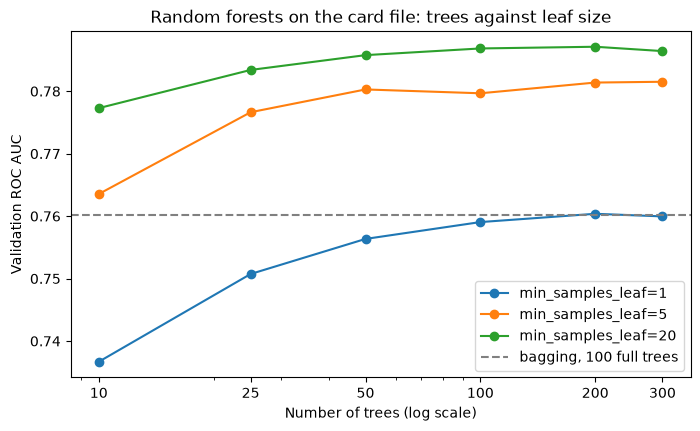

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
for leaf, aucs in auc_by_trees.items():
    ax.plot(tree_counts, aucs, marker="o", label=f"min_samples_leaf={leaf}")
ax.axhline(roc_auc_score(y_valid, proba_bag), color="grey", linestyle="--", label="bagging, 100 full trees")
ax.set_xscale("log")
ax.set_xticks(tree_counts)
ax.set_xticklabels([str(k) for k in tree_counts])
ax.set_title("Random forests on the card file: trees against leaf size")
ax.set_xlabel("Number of trees (log scale)")
ax.set_ylabel("Validation ROC AUC")
ax.legend()
plt.show()

* Each line flattens after about 50 trees; the gaps between the lines stay. More trees never hurt a forest's validation ROC AUC much, but on this file they cannot make up for leaves that are too small.

## 3.5 `max_features=None` Is Bagging

With `max_features=None` every split may use all 19 columns. Then a random forest is the same recipe as day 2's bagging: full trees, each on a bootstrap sample of the training rows, averaged. The two classes draw their random numbers differently, so the trees are not the same trees, but the method is the same.

Q. Fit a forest of 100 trees with `max_features=None` and set it beside the bagged model.

In [17]:
# every split may use every column: bagging under the forest's name
all_columns = RandomForestClassifier(n_estimators=100, max_features=None, random_state=SEED, n_jobs=1)
all_columns.fit(X_train, y_train)
proba_all = all_columns.predict_proba(X_valid)[:, 1]

first_all = pd.Series([X_train.columns[tree.tree_.feature[0]] for tree in all_columns.estimators_])
print(f"columns tried at each split: {all_columns.estimators_[0].max_features_}; first question about: {first_all.value_counts().to_dict()}")
print(f"forest, max_features=None: validation ROC AUC {roc_auc_score(y_valid, proba_all):.4f}, "
      f"tree correlation {ensemblekit.tree_correlation(all_columns, X_valid):.4f}")
print(f"bagging, 100 full trees:   validation ROC AUC {roc_auc_score(y_valid, proba_bag):.4f}, "
      f"tree correlation {ensemblekit.tree_correlation(bagging, X_valid):.4f}")

columns tried at each split: 19; first question about: {'PAY_0': 100}


forest, max_features=None: validation ROC AUC 0.7595, tree correlation 0.2577


bagging, 100 full trees:   validation ROC AUC 0.7602, tree correlation 0.2581


* Every split tried all 19 columns, every tree asks about `PAY_0` first, and the forest lands where bagging does: 0.7595 against 0.7602, tree correlation 0.2577 against 0.2581. Equal settings, nearly equal numbers. A "random forest" with `max_features=None` is bagging with another class name, which is the bug in today's AI check.

## 3.6 Class Weights in a Forest

About 22.1 percent of the training accounts defaulted. `class_weight="balanced"` gives each class the weight n / (2 x its count), so the defaults count as much in total as the rest when trees choose their splits. `"balanced_subsample"` computes the same weights again inside each tree's bootstrap sample.

Q. What are the balanced weights on the training rows, and what do they do to a forest with 5-row leaves?

In [18]:
from sklearn.utils.class_weight import compute_class_weight

# n / (2 x count of the class): the weight each row of that class gets
weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
print(f"balanced weights: no default {weights[0]:.4f}, default {weights[1]:.4f}")

proba_leaf5 = by_leaf[5]["forest"].predict_proba(X_valid)[:, 1]
outputs = {"no weights": proba_leaf5}
for class_weight in ["balanced", "balanced_subsample"]:
    weighted = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight=class_weight, random_state=SEED,
                                      n_jobs=1).fit(X_train, y_train)
    outputs[class_weight] = weighted.predict_proba(X_valid)[:, 1]
proba_balanced = outputs["balanced"]

for name, output in outputs.items():
    print(f"300 trees, 5-row leaves, {name}: validation ROC AUC {roc_auc_score(y_valid, output):.4f}, "
          f"average precision {average_precision_score(y_valid, output):.4f}, mean output {output.mean():.4f}")
print(f"default rate of the validation rows: {y_valid.mean():.4f}")

balanced weights: no default 0.6420, default 2.2602


300 trees, 5-row leaves, no weights: validation ROC AUC 0.7815, average precision 0.5448, mean output 0.2223
300 trees, 5-row leaves, balanced: validation ROC AUC 0.7806, average precision 0.5386, mean output 0.3735
300 trees, 5-row leaves, balanced_subsample: validation ROC AUC 0.7795, average precision 0.5424, mean output 0.3217
default rate of the validation rows: 0.2212


* Each default counts 2.2602 and each other account 0.6420.
* The ranking hardly moves: 0.7815 without weights, 0.7806 balanced, 0.7795 balanced by subsample. What moves is the level. Without weights the forest's mean output, 0.2223, sits near the validation default rate, 0.2212; with weights it is 0.3735 and 0.3217. A weighted forest's output is the model's score, not a probability: it ranks the accounts about as well, and its average sits far above the default rate. Day 13 shows how to bring such a score back to the outcome rate.

## 3.7 Choosing a Leaf Size on the Training Rows

Section 3.4 compared leaf sizes on the validation rows. That was to look, not to choose: Course 5 chooses nothing on the validation rows. A setting is chosen by cross-validation inside the training rows, as Course 4 chose its pruning level, and the validation rows report the chosen model once.

A search over forests is slow on one thread, so this one is small: six leaf sizes, forests of 50 trees (section 3.4 showed 50 trees land close to 300), five folds of the training rows.

Q. Choose `min_samples_leaf` by five folds of the training rows.

In [19]:
from sklearn.model_selection import GridSearchCV

# six candidates, each scored by ROC AUC on five folds of the training rows; the validation rows take no part
search = GridSearchCV(RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=1),
                      {"min_samples_leaf": [5, 10, 20, 40, 80, 160]}, cv=mlkit.cv_folds(), scoring="roc_auc", n_jobs=1)
search.fit(X_train, y_train)

folds = pd.DataFrame(search.cv_results_)[["param_min_samples_leaf", "mean_test_score", "std_test_score", "rank_test_score"]]
print(folds.round(4).to_string(index=False))
print(f"chosen min_samples_leaf: {search.best_params_['min_samples_leaf']}, mean of five folds {search.best_score_:.4f}")

 param_min_samples_leaf  mean_test_score  std_test_score  rank_test_score
                      5           0.7709          0.0045                6
                     10           0.7767          0.0044                5
                     20           0.7800          0.0039                4
                     40           0.7827          0.0025                1
                     80           0.7826          0.0028                2
                    160           0.7820          0.0023                3
chosen min_samples_leaf: 40, mean of five folds 0.7827


* The search chooses leaves of at least 40 rows, with a mean of 0.7827 over the five folds (standard deviation 0.0025). The runner-up, 80 rows, is 0.0001 behind, less than one fold standard deviation: on this file a wide range of large leaves does about equally well, and the small leaves do worst.
* That fold mean is the best of six noisy numbers, so it flatters the chosen setting a little. Day 11 measures how much, with a nested score.

Q. Score the chosen forest once on the validation rows.

In [20]:
# GridSearchCV refits the chosen setting on all the training rows; the validation rows report it
proba_searched = search.best_estimator_.predict_proba(X_valid)[:, 1]
print(f"searched forest, 50 trees, min_samples_leaf={search.best_params_['min_samples_leaf']}: "
      f"validation ROC AUC {roc_auc_score(y_valid, proba_searched):.4f}, "
      f"average precision {average_precision_score(y_valid, proba_searched):.4f}")

searched forest, 50 trees, min_samples_leaf=40: validation ROC AUC 0.7844, average precision 0.5534


* 0.7844 on the validation rows, chosen without them, close to the 20-row forest of section 3.4 (0.7864). The choice was made on the training rows alone; the validation rows only reported it.

## 3.8 Extremely Randomized Trees

`ExtraTreesClassifier` goes one step further than a forest: at each split it also draws the threshold of each candidate column at random instead of searching for the best one, then keeps the best of those random questions. By default it also fits every tree on all the training rows, with no bootstrap.

Q. Fit 300 extremely randomized trees with 5-row leaves.

In [21]:
from sklearn.ensemble import ExtraTreesClassifier

# random thresholds as well as random columns; every tree sees all the training rows (bootstrap=False by default)
extra = ExtraTreesClassifier(n_estimators=300, min_samples_leaf=5, random_state=SEED, n_jobs=1)
extra.fit(X_train, y_train)
proba_extra = extra.predict_proba(X_valid)[:, 1]
print(f"extra trees, 300, 5-row leaves: validation ROC AUC {roc_auc_score(y_valid, proba_extra):.4f}, "
      f"average precision {average_precision_score(y_valid, proba_extra):.4f}, "
      f"tree correlation {ensemblekit.tree_correlation(extra, X_valid):.4f}")
print(f"random forest, 300, 5-row leaves: validation ROC AUC {roc_auc_score(y_valid, proba_leaf5):.4f}, "
      f"tree correlation {by_leaf[5]['tree correlation']:.4f}")

extra trees, 300, 5-row leaves: validation ROC AUC 0.7814, average precision 0.5490, tree correlation 0.6868
random forest, 300, 5-row leaves: validation ROC AUC 0.7815, tree correlation 0.4116


* The extra trees rank the validation accounts like the forest with the same leaves (0.7814 against 0.7815), and their trees agree more (0.6868 against 0.4116); unlike the forest's trees, every one of them was fitted on the same rows. The output is the model probability of default in this file. One fit is enough to know the class exists; the course does not tune it.

## Excel Side by Side

Excel has no worksheet function for a random forest, or for any tree. What Excel can do is the arithmetic around one: how many columns a split tries, the chance a column is among them, how much two trees' pasted outputs agree, the class weights, and the summary of a search's fold scores. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Columns tried per split, `"sqrt"` | `forest.estimators_[0].max_features_` | `=INT(SQRT(19))` | 4 |
| Columns tried per split, `0.5` | `max_features_` of a forest with `max_features=0.5` | `=INT(0.5*19)` | 9 |
| Chance a given column is tried | `1 - comb(18, 4) / comb(19, 4)` | `=1-COMBIN(18,4)/COMBIN(19,4)` | 0.2105 |
| Agreement of two trees | `np.corrcoef(a, b)[0, 1]` | `=CORREL(B2:B6001,C2:C6001)` | bagging 0.2564, forest 0.2362 |
| Mean agreement of five trees | upper triangle of `np.corrcoef`, averaged | ten `=CORREL` pairs in H1:H10, then `=AVERAGE(H1:H10)` | 0.2455 |
| Balanced weight of a default | `compute_class_weight("balanced", ...)` | `=ROWS(A2:A18001)/(2*COUNTIF(A2:A18001,1))` | 2.2602 |
| Balanced weight of a non-default | the same | `=ROWS(A2:A18001)/(2*COUNTIF(A2:A18001,0))` | 0.6420 |
| The search's mean of five folds | `mean_test_score` | `=AVERAGE(C1:C5)` | 0.7827 |
| Their standard deviation | `std_test_score` | `=STDEV.P(C1:C5)` | 0.0025 |

**Columns per split.** `=INT(SQRT(19))` is scikit-learn's rule for `"sqrt"`: the square root, whole part kept. For a fraction such as `max_features=0.5`, scikit-learn keeps the whole part of the fraction times the column count, and `=INT(0.5*19)` gives the same 9 a fitted tree reports.

**The chance a column is tried.** `COMBIN(19,4)` counts the ways to draw 4 columns from 19; `COMBIN(18,4)` the ways that leave out one given column. One minus their ratio is the chance that column is among the 4.

**Agreement.** With two trees' validation outputs pasted side by side in B and C, one row per account, `=CORREL(B2:B6001,C2:C6001)` is the correlation `np.corrcoef` gives. With five trees pasted in B to F, ten `CORREL` formulas cover every pair once, and their `AVERAGE` is what `tree_correlation` computes for five trees.

**Class weights.** With the 18,000 training labels pasted in column A, `ROWS` counts the rows and `COUNTIF` the rows of one class: n / (2 x count) is the balanced weight.

**Fold scores.** With the chosen candidate's five fold scores (`split0_test_score` to `split4_test_score` in `cv_results_`) pasted in C1:C5, `AVERAGE` gives `mean_test_score` and `STDEV.P` gives `std_test_score`. `STDEV.S` divides by 4 instead of 5 and gives a different number (tested by the course's Excel checks), so use `STDEV.P`.

Q. Do Excel's numbers equal Python's?

In [22]:
first_five = tree_outputs(forest, X_valid)[:5]
best = search.best_index_
# Excel's numbers, from the course's Excel checks, beside Python's for the same rows
excel = {"chance a given column is tried": 0.21052631578947367,
         "correlation, bagging trees 1 and 2": 0.2563688267415541,
         "correlation, forest trees 1 and 2": 0.2362011254516237,
         "mean correlation, forest trees 1 to 5": 0.24549581153057312,
         "balanced weight of a default": 2.260170768458061,
         "search: mean of five folds": 0.7826818771708453,
         "search: STDEV.P of five folds": 0.0025182511162741626}
python = {"chance a given column is tried": chance,
          "correlation, bagging trees 1 and 2": np.corrcoef(bag_outputs[0], bag_outputs[1])[0, 1],
          "correlation, forest trees 1 and 2": np.corrcoef(first_five[0], first_five[1])[0, 1],
          "mean correlation, forest trees 1 to 5": np.corrcoef(first_five)[np.triu_indices(5, k=1)].mean(),
          "balanced weight of a default": weights[1],
          "search: mean of five folds": search.cv_results_["mean_test_score"][best],
          "search: STDEV.P of five folds": search.cv_results_["std_test_score"][best]}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
print(side_by_side.to_string())

                                          Excel    Python  within 1e-12
chance a given column is tried         0.210526  0.210526          True
correlation, bagging trees 1 and 2     0.256369  0.256369          True
correlation, forest trees 1 and 2      0.236201  0.236201          True
mean correlation, forest trees 1 to 5  0.245496  0.245496          True
balanced weight of a default           2.260171  2.260171          True
search: mean of five folds             0.782682  0.782682          True
search: STDEV.P of five folds          0.002518  0.002518          True


* Every number matches within 1e-12. The correlations differ in the 14th decimal place, two ways of adding up 6,000 products, so the comparison is printed as "within 1e-12" rather than as the gap itself.

## Save the Day with Git

Every day's work folder starts fresh, so today's repository starts with today's files: Course 4's `mlkit.py`, unchanged, and `ensemblekit.py` and its tests with today's function. Then the experiment log goes in two commits, so its history has something to show.

Q. Make the work folder a repository.

In [23]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1

Q. Is Git working in the work folder, and only there?

In [24]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_03_6eve2eqj and nowhere else


Q. Tell Git which files never to track, and commit the code.

In [25]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [26]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "Add tree_correlation: how much an ensemble's trees agree, 14 tests"
!git -C "{work}" show --stat --format=%s HEAD

Add tree_correlation: how much an ensemble's trees agree, 14 tests

 .gitignore          |   3 +
 ensemblekit.py      | 155 ++++++++++++++
 mlkit.py            | 568 ++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_ensemblekit.py | 192 ++++++++++++++++++
 4 files changed, 918 insertions(+)


Q. Write the first two rows of the experiment log, bagging and the full-tree forest, and commit them.

In [27]:
def log_rows(models: dict) -> pd.DataFrame:
    """One row per model: validation ranking metrics, and flags at 0.5 scored by mlkit.classification_metrics."""
    rows = []
    for name, output in models.items():
        metrics = mlkit.classification_metrics(y_valid, (output >= 0.5).astype(int))
        rows.append({"model": name, "rows": "validation", "roc_auc": roc_auc_score(y_valid, output),
                     "average_precision": average_precision_score(y_valid, output), "threshold": 0.5, **metrics})
    return pd.DataFrame(rows)


logged = {"bagging_100_full_trees": proba_bag, "random_forest_300_full_trees": proba_forest}
# 4 decimals and LF line endings, so a later diff shows only real changes
log_rows(logged).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
bagging_100_full_trees,validation,0.7602,0.5105,0.5000,0.8143,0.6357,0.3760,0.4725
random_forest_300_full_trees,validation,0.7600,0.5146,0.5000,0.8153,0.6402,0.3768,0.4744



In [28]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: bagging and a random forest of full trees, validation rows"

Q. Add the other forests of the day to the log, and commit again.

In [29]:
logged.update({"random_forest_300_leaf_5": proba_leaf5, "random_forest_300_leaf_20": by_leaf[20]["forest"].predict_proba(X_valid)[:, 1],
               "random_forest_300_leaf_5_balanced": proba_balanced,
               f"random_forest_50_leaf_{search.best_params_['min_samples_leaf']}_searched": proba_searched,
               "extra_trees_300_leaf_5": proba_extra})
log_rows(logged).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))
print(f"accuracy of flagging no account (all-zero baseline) on the validation rows: {1 - y_valid.mean():.4f}")

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
bagging_100_full_trees,validation,0.7602,0.5105,0.5000,0.8143,0.6357,0.3760,0.4725
random_forest_300_full_trees,validation,0.7600,0.5146,0.5000,0.8153,0.6402,0.3768,0.4744
random_forest_300_leaf_5,validation,0.7815,0.5448,0.5000,0.8175,0.6643,0.3534,0.4614
random_forest_300_leaf_20,validation,0.7864,0.5552,0.5000,0.8185,0.6750,0.3459,0.4574
random_forest_300_leaf_5_balanced,validation,0.7806,0.5386,0.5000,0.7818,0.5060,0.5750,0.5383
random_forest_50_leaf_40_searched,validation,0.7844,0.5534,0.5000,0.8198,0.6814,0.3482,0.4608
extra_trees_300_leaf_5,validation,0.7814,0.5490,0.5000,0.8202,0.6782,0.3557,0.4666

accuracy of flagging no account (all-zero baseline) on the validation rows: 0.7788


* By validation ROC AUC the 20-row forest ranks the accounts best (0.7864). The threshold is 0.5 for every model, as on day 1; from day 5 it comes from out-of-fold probabilities on the training rows.
* The balanced forest's recall at 0.5 is 0.5750 against 0.3534 for the same forest without weights, with almost the same ROC AUC: its score is shifted up, so more accounts clear 0.5. A flag at a fixed threshold depends on the level of the output; the ranking does not. Accuracy is printed beside the all-zero baseline (0.7788) and never used to choose.

In [30]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: leaf sizes, class weights, the searched forest, extra trees"

Q. Today's Git step: which commits touched `results.csv`?

In [31]:
# the whole history, then only the commits that changed results.csv
!git -C "{work}" log --oneline
!git -C "{work}" log --oneline -- results.csv

791015d Experiment log: leaf sizes, class weights, the searched forest, extra trees
5896a15 Experiment log: bagging and a random forest of full trees, validation rows
d91331f Add tree_correlation: how much an ensemble's trees agree, 14 tests


791015d Experiment log: leaf sizes, class weights, the searched forest, extra trees
5896a15 Experiment log: bagging and a random forest of full trees, validation rows


* `git log --oneline` lists all three commits; adding `-- results.csv` keeps only the two that changed the log. With a path after `--`, Git shows the history of that file alone: a quick way to see when an experiment log changed, and with which message, without the code commits in between.

## Bring It Home

Add today's function to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Go to the folder. The card file is already there from day 1.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code ensemblekit.py
code test_ensemblekit.py
```

**Step 2.** Paste the code of today's `%%writefile -a ensemblekit.py` cell (section 3.1), without its first line, at the end of `ensemblekit.py`; do the same for the `%%writefile -a test_ensemblekit.py` cell. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_ensemblekit.py
```

The last line says `14 passed`.

**Step 4.** Read the change, commit it, and look at one file's history.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "Add tree_correlation: how much an ensemble's trees agree, 14 tests"
git log --oneline -- ensemblekit.py
```

The last line lists only the commits that changed `ensemblekit.py`: day 1's, day 2's, and today's.

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Measure how much an ensemble's trees agree with `tree_correlation`, and say why agreement limits what averaging removes.
* Say what `max_features` does, and work out the columns a split tries for `"sqrt"` and for a fraction.
* Show that a forest's trees start from different questions, and that `max_features=None` is bagging.
* Show on the card file that leaf size moves a forest more than tree count, and that better single trees can beat lower correlation.
* Say what class weights do to a forest's output: about the same ranking, a higher level, so the model's score.
* Choose a leaf size by five folds of the training rows and report the chosen forest once on the validation rows.
* List only the commits that changed one file with `git log --oneline -- results.csv`.

Tomorrow, day 4: the forest's two importances, impurity and permutation, and a column of random numbers that one of them ranks near the top.

## Exercises

The exercises use Course 4's card rows: fitted on the 18,000 training rows, scored on the 6,000 validation rows, the test rows closed. The four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card rows and defines `check`, a small function that marks your answers.

In [32]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier

# Course 4's training and validation rows of the card file
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Fit a forest of 300 trees with 5-row leaves (`min_samples_leaf=5`, `random_state=SEED`, `n_jobs=1`) on the training rows **without the `PAY_0` column**, and store its validation ROC AUC (scored on the validation rows without `PAY_0`) in **ex1_auc**. Section 3.4's forest with all 19 columns ranked them at 0.7815.

In [33]:
ex1_auc = ...

In [34]:
check("Exercise 1 the forest without PAY_0", ex1_auc, 0.7513981052627845)

Exercise 1 the forest without PAY_0: not attempted yet


### Exercise 2

Q. Fit a forest of 300 trees with 5-row leaves and `max_features=0.5`. Store its validation ROC AUC in **ex2_auc** and its tree correlation on the validation rows in **ex2_correlation**. How many columns does each split try?

In [35]:
ex2_auc = ...
ex2_correlation = ...

In [36]:
check("Exercise 2 the ROC AUC", ex2_auc, 0.7761374607708895)
check("Exercise 2 the tree correlation", ex2_correlation, 0.4016735142148362)

Exercise 2 the ROC AUC: not attempted yet
Exercise 2 the tree correlation: not attempted yet


### Exercise 3

Q. Add a function to your module. `forest_settings(forest)` returns a dict with three keys: `trees` (how many trees were fitted), `leaf_size` (`min_samples_leaf`), and `columns_per_split` (the first tree's `max_features_`, as an `int`); it raises `ValueError` if the forest is not fitted. Write the docstring first. Then add `test_forest_settings_small_forest`, which fits a 3-tree forest with `min_samples_leaf=10` and `max_features=0.5` on `card_small(500)` and checks the dict, and checks that an unfitted forest raises `ValueError`. Run pytest, reload the module, and store `ensemblekit.forest_settings(...)` of a forest of 20 trees with 5-row leaves fitted on the first 2,000 training rows (`random_state=SEED`, `n_jobs=1`) in **ex3_settings**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [37]:
%%writefile -a ensemblekit.py


# Exercise 3: write forest_settings(forest) below this line

Appending to ensemblekit.py


In [38]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_forest_settings_small_forest() below this line

Appending to test_ensemblekit.py


In [39]:
# run pytest, reload the module, then call your function
ex3_settings = ...

In [40]:
check("Exercise 3 forest_settings", ex3_settings, {'trees': 20, 'leaf_size': 5, 'columns_per_split': 4})

Exercise 3 forest_settings: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that fits a random forest, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fit a random forest of n_trees full trees on X and y, seeded with SEED.

    Each tree is fitted on a bootstrap sample of the rows, and each split chooses among a random subset of
    the columns (the square root of the number of columns), so the trees agree less than the trees of a
    bagged model fitted on the same rows.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a fitted `RandomForestClassifier`, and contains one bug.

In [41]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def fit_random_forest(X, y, n_trees=50):
    """Fit a random forest of n_trees full trees on X and y, seeded with SEED.

    Each tree is fitted on a bootstrap sample of the rows, and each split chooses among a random subset of
    the columns (the square root of the number of columns), so the trees agree less than the trees of a
    bagged model fitted on the same rows.
    """
    # consider every column at every split, so no tree misses the best question
    forest = RandomForestClassifier(n_estimators=n_trees, max_features=None, random_state=SEED, n_jobs=1)
    return forest.fit(X, y)

Q. Before you run the next cell: will this forest's trees agree less than the trees of a bagged model, as the docstring says?

In [42]:
ai_forest = fit_random_forest(X_train, y_train)
print(f"{type(ai_forest).__name__} of {len(ai_forest.estimators_)} trees: "
      f"validation ROC AUC {roc_auc_score(y_valid, ai_forest.predict_proba(X_valid)[:, 1]):.4f}")

RandomForestClassifier of 50 trees: validation ROC AUC 0.7591


Q. Test the function against its docstring before you trust it.

In [43]:
# the test, written from the docstring before the code is trusted
ai_forest = fit_random_forest(X_train, y_train)
# a bagged model of as many full trees on the same rows, to compare with
reference_bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=50, random_state=SEED,
                                      n_jobs=1).fit(X_train, y_train)
columns_tried = ai_forest.estimators_[0].max_features_
ai_correlation = ensemblekit.tree_correlation(ai_forest, X_valid)
bagging_correlation = ensemblekit.tree_correlation(reference_bagging, X_valid)

# 1. a random subset of the columns at each split, not all of them
assert columns_tried < X_train.shape[1], f"every split tried all {columns_tried} columns: bagging, not a random forest"
# 2. its trees agree less than the bagged model's trees
assert ai_correlation < bagging_correlation, "the trees agree as much as bagged trees do"
print(f"columns per split {columns_tried}; tree correlation {ai_correlation:.4f} against bagging's {bagging_correlation:.4f}")

AssertionError: every split tried all 19 columns: bagging, not a random forest

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed forest's tree correlation on the validation rows, `ensemblekit.tree_correlation(fit_random_forest(X_train, y_train), X_valid)`, in **ex4_correlation**.

In [44]:
# fix the function above and run the test again, then store the answer
ex4_correlation = ...

In [45]:
check("Exercise 4 the fixed forest's tree correlation", ex4_correlation, 0.2491438850541977)

Exercise 4 the fixed forest's tree correlation: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```